In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================

# Data processing
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Time series (kept inline for EDA visualization)
from statsmodels.tsa.seasonal import seasonal_decompose

# Make the `src` package importable from the notebooks/ folder
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src import config, setup, data, modeling, evaluation, export, tracking, pipeline

print("✅ All imports loaded successfully")
print(f"📊 Configuration: {config.EXPERIMENT_NAME}")

✅ All imports loaded successfully
📊 Configuration: Superstore_Sales_Forecast


# Superstore Sales Forecasting with SARIMAX

> **Note:** MLflow tracking is optional. If not installed, this notebook will run successfully with all core functionality (statsmodels, sklearn, matplotlib, pandas) fully operational.

In [2]:
# Setup cell for local execution
setup.ensure_directories()

if setup.verify_data_file():
    print(f"✓ Found: {config.relative_path(config.RAW_DATA_PATH)}")
else:
    print(f"✗ Not found: {config.relative_path(config.RAW_DATA_PATH)}")

✓ data\raw
✓ output
✓ mlruns
✓ Found: data\raw\Superstore.xlsx


## Overview

Sales forecasting is the process of predicting future sales based on historical data and observed patterns. Accurate forecasts enable proactive planning rather than reactive decision-making. This notebook demonstrates a professional approach to demand forecasting using the SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) model.

### Why Sales Forecasting Matters

- **Inventory Planning:** Ensure stock levels match demand without overcommitting capital
- **Resource Allocation:** Set realistic sales targets and direct resources to high-potential segments
- **Cash Flow Management:** Predict future revenue to optimize budgets and investments

### Workflow

This notebook follows five key stages:

1. **Data Loading** - Import sales data from local files
2. **Exploratory Data Analysis (EDA)** - Understand data characteristics, trends, and seasonality
3. **Data Preprocessing** - Clean and prepare data for modeling
4. **Model Training & Evaluation** - Train SARIMAX model and track performance metrics
5. **Forecasting & Results** - Generate predictions and export outputs for analysis

## Import Libraries and Configuration

In [3]:
try:
    import mlflow
    from mlflow.statsmodels import autolog
    MLFLOW_AVAILABLE = True
    print("✅ MLflow imported successfully")
except Exception as e:
    MLFLOW_AVAILABLE = False
    print("❌ MLflow import failed with error:")
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {str(e)}")
    import traceback
    traceback.print_exc()

✅ MLflow imported successfully


In [4]:
# Download demo dataset if not using custom data
if not config.IS_CUSTOM_DATA:
    data.download_demo_dataset()
    print("Demo dataset successfully downloaded.")

Demo dataset successfully downloaded.


In [5]:
# Initialize MLflow experiment tracking
if MLFLOW_AVAILABLE:
    tracking.init_mlflow(config.EXPERIMENT_NAME, config.MLRUNS_DIR)

## Step 1: Load Data

In [6]:
# Load data from Excel file
real_df = data.load_raw_data()
df = real_df.copy()

# Display first few rows
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

We maintain a separate copy of the original data to ensure data integrity throughout the analysis process. All cleaning and transformations are performed on the working copy (`df`), allowing us to return to the original data if needed for validation or debugging.

## Step 2: Exploratory Data Analysis (EDA)

### Data Overview

We begin by examining the dataset structure, data types, and temporal coverage to ensure quality and completeness.

In [7]:
# Display dataset information
print(df.info())

# Display date range
print(
    "First order date :", df["Order Date"].min().strftime("%Y-%m-%d"),
    "\nLast order date :", df["Order Date"].max().strftime("%Y-%m-%d")
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

The dataset contains 9,994 rows and 21 columns with no missing values, indicating good data quality. The temporal coverage spans from 2014-01-03 to 2017-12-30, providing four years of complete historical data suitable for time series analysis.

### Duplicate Detection

Verifying data uniqueness ensures calculation accuracy and prevents bias in model training.

In [8]:
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


No duplicate rows detected, confirming data integrity.

### Data Preprocessing

For this analysis, we focus on total sales forecasting across the entire organization. We remove granular attributes (customer IDs, regional details, product-level information) to isolate overall business trends.

In [9]:
# Remove non-essential columns and sort by date
df = data.preprocess(df)

# Check for null values
print(df.isnull().sum())

Order Date    0
Sales         0
dtype: int64


### Time Series Aggregation and Visualization

We aggregate daily transactions into monthly averages to smooth noise and reveal underlying business patterns. This resampling captures seasonal trends more clearly than daily data.

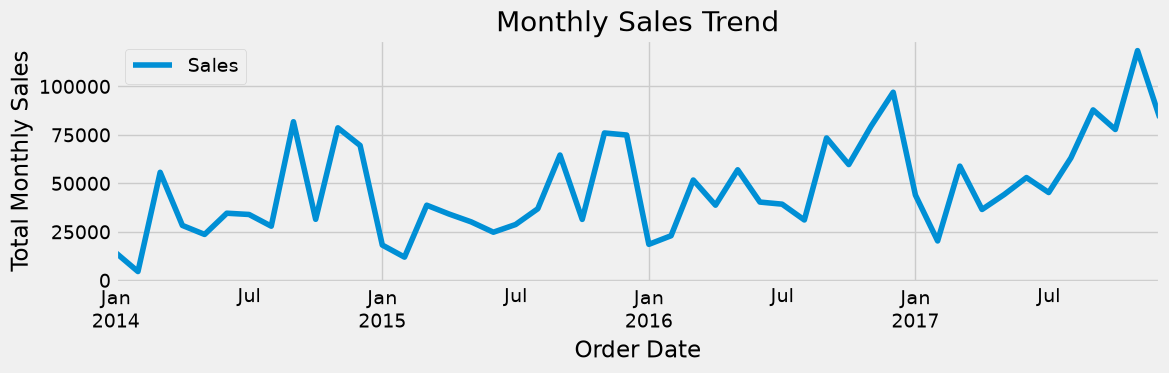

In [10]:
# Aggregate daily sales into a monthly series
y, maximum_date = data.aggregate_monthly(df)

# Visualize sales trend
y.plot(figsize=(12, 3))
plt.title("Monthly Sales Trend")
plt.ylabel("Total Monthly Sales")
plt.show()

### Trend and Seasonality Interpretation

The visualization reveals:
- **Upward Trend:** Sales show gradual growth over time
- **Seasonal Pattern:** Regular peaks and troughs recur annually
- **Steady Fluctuations:** Changes follow a predictable rhythm rather than random noise

These characteristics confirm that SARIMAX is an appropriate choice for this dataset.

### Time Series Decomposition

We decompose the time series into trend, seasonality, and residual components to understand the underlying structure.

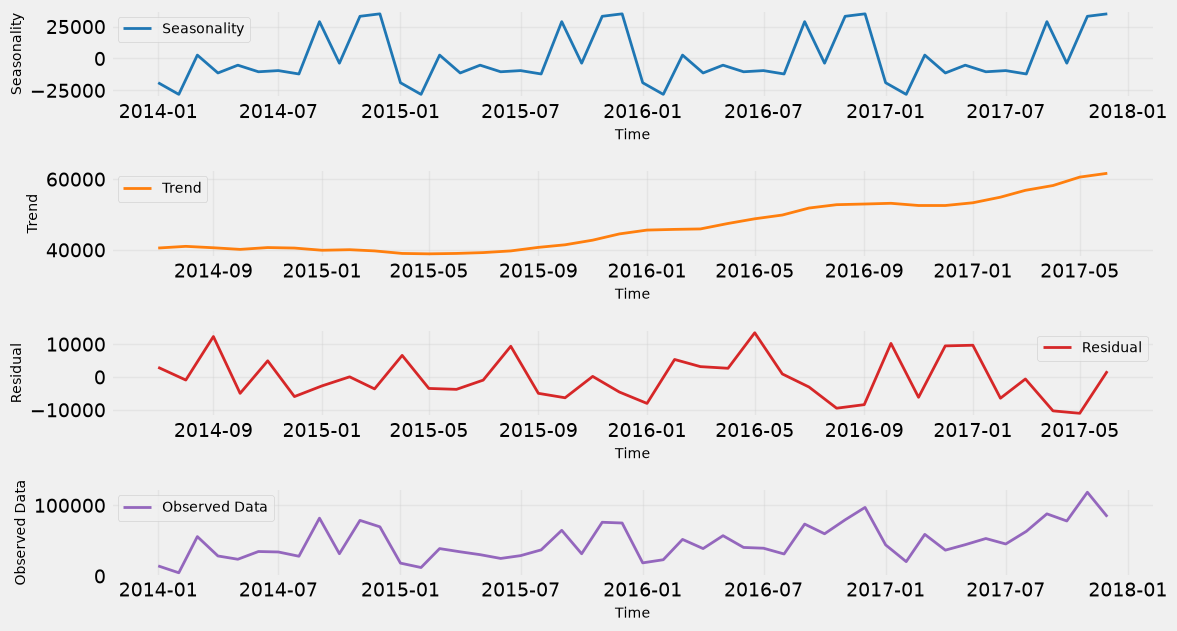

In [11]:
# Decompose time series into components
result = seasonal_decompose(y, model='additive')

# Prepare components for visualization
components = [
    ('Seasonality', result.seasonal),
    ('Trend', result.trend),
    ('Residual', result.resid),
    ('Observed Data', y)
]

# Define colors
colors = {
    'Seasonality': 'tab:blue',
    'Trend': 'tab:orange',
    'Residual': 'tab:red',
    'Observed Data': 'tab:purple'
}

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 7))
plt.subplots_adjust(hspace=0.8)
axes = axes.ravel()

# Plot each component
for ax, (label, data_) in zip(axes, components):
    ax.plot(data_, label=label, color=colors[label], linewidth=2)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.show()

### Decomposition Results

The decomposition confirms:
- **Seasonality:** Strong, consistent annual pattern
- **Trend:** Steady upward progression over time
- **Residuals:** Random variation around zero, indicating good model fit

This validates our choice of SARIMAX, which explicitly models both trend and seasonal components.

## Step 3: Model Training & Evaluation

### SARIMAX Model Selection

SARIMAX is chosen because it explicitly captures trend and seasonal patterns, the dominant characteristics of sales data. The model uses two parameter sets:
- **Order (p, d, q):** Controls trend components
- **Seasonal Order (P, D, Q, s):** Controls seasonal patterns

### Model Comparison

| Method | Strengths | Why Not Chosen |
|:---|:---|:---|
| **Holt-Winters** | Simple, interpretable | Limited external variable support |
| **Prophet** | Handles holidays well | Less precise statistical control |
| **Machine Learning** | Captures non-linear patterns | Requires extensive feature engineering |
| **Deep Learning** | Powerful for large data | Complex, difficult to interpret |

### Evaluation Metrics

- **AIC:** Model selection criterion (lower is better)
- **MAPE:** Percentage error for business communication
- **Ljung-Box Test:** Validates residual randomness

### Hyperparameter Tuning

We perform grid search over parameter ranges to find the optimal configuration.

In [12]:
# Run the same leakage-free training and validation flow used by the CLI.
# Model selection uses only the training portion; the final model is then
# retrained on all historical data before producing the future forecast.
pipeline_result = pipeline.run(
    y,
    validation_months=config.VALIDATION_MONTHS,
    forecast_months=config.FORECAST_MONTHS
)

d, D = None, None
aic_df = pipeline_result['aic']
order = pipeline_result['order']
seasonal_order = pipeline_result['seasonal_order']
results = pipeline_result['results']
pred = pipeline_result['prediction']
pred_ci = pipeline_result['prediction_ci']
predictions = pipeline_result['validation_prediction']
mape = pipeline_result['mape']

print(f"Selected order={order}, seasonal_order={seasonal_order}")
print(aic_df.head())
print(f"Leakage-free validation MAPE: {mape:.2f}%")

Selected order=(0, 0, 0), seasonal_order=(0, 1, 2, 12)
       order seasonal_order  AIC
0  (0, 0, 0)  (0, 1, 2, 12)  6.0
1  (0, 0, 0)  (2, 1, 0, 12)  6.0
2  (1, 0, 0)  (2, 1, 0, 12)  8.0
3  (1, 0, 0)  (0, 1, 2, 12)  8.0
4  (0, 0, 0)  (1, 1, 2, 12)  8.0
Leakage-free validation MAPE: 24.52%


### Best Model Configuration

The differencing orders (d, D) are fixed upfront via ADF stationarity tests (see printed output above), then the model with the lowest AIC from the grid search over the remaining parameters (p, q, P, Q) is selected programmatically below — no configuration is hardcoded.

**Non-Seasonal Parameters (p, d, q):** p controls direct autoregressive dependency, d is the ADF-determined trend differencing, q controls moving-average error correction.

**Seasonal Parameters (P, D, Q, s):** P controls seasonal autoregression, D is the ADF-determined seasonal differencing, Q controls seasonal moving-average correction, s=12 for annual seasonality.

Because d and D are held constant across all candidates, AIC values in the grid search are directly comparable, and the lowest-AIC row is a valid choice.

### Train Final Model

In [13]:
# The model was selected on the training split and retrained on all data
# by pipeline.run(). Display the final fitted model summary.
print(results.summary())

                                   SARIMAX Results                                   
Dep. Variable:                         Sales   No. Observations:                   48
Model:             SARIMAX(0, 1, [1, 2], 12)   Log Likelihood                -122.845
Date:                       Tue, 15 Sep 2026   AIC                            251.689
Time:                               14:29:16   BIC                            252.883
Sample:                           01-01-2014   HQIC                           250.937
                                - 12-01-2017                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12       0.1163      0.097      1.199      0.230      -0.074       0.306
ma.S.L24      -0.4804      0.453     -1.060      0.289      -1.369       0.

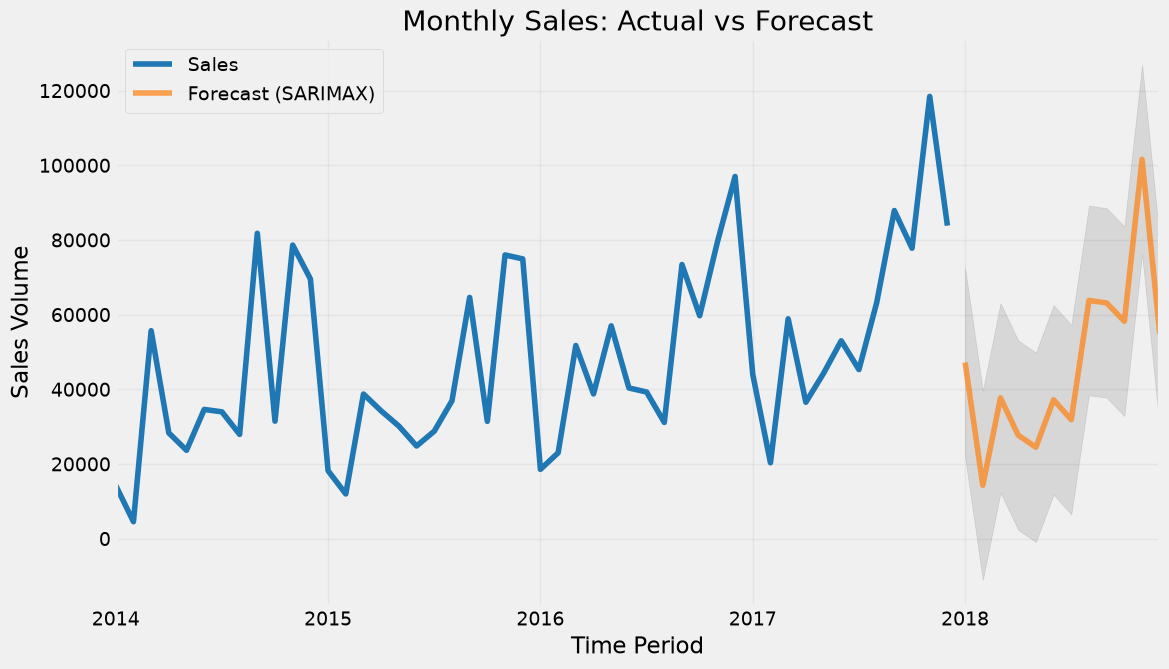

In [14]:
# Generate forecast predictions for visualization and export (FORECAST_MONTHS ahead)
pred, pred_ci = evaluation.forecast(results, maximum_date, config.FORECAST_MONTHS)

# Create visualization
ax = y.plot(label='Actual Sales (Historical)', color='#1f77b4')
pred.predicted_mean.plot(
    ax=ax, 
    label='Forecast (SARIMAX)', 
    color='#ff7f0e',
    alpha=.7, 
    figsize=(12, 7)
)

# Add confidence interval shading
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1], 
    color='k', 
    alpha=.1
)

# Format plot
ax.set_xlabel('Time Period')
ax.set_ylabel('Sales Volume')
plt.title('Monthly Sales: Actual vs Forecast')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### Forecast Analysis

The visualization shows:
- **Good Alignment:** Forecast follows historical trends closely
- **Realistic Projection:** No extreme or unrealistic values
- **Confidence Bounds:** Uncertainty increases over longer horizons (expected behavior)

The model demonstrates solid predictive capability for business planning.

In [15]:
# Log model to MLflow if available
if MLFLOW_AVAILABLE:
    model_uri = tracking.log_sarimax_run(results, order, seasonal_order, config.EXPERIMENT_NAME)
    print(f"Model URI: {model_uri}")
else:
    print("⚠️  MLflow not available - model logging skipped")

Model URI: runs:/4796a90ca7d44fb4ab67308d27b5fe9c/Superstore_Sales_Forecast-Sarimax


Registered model 'Superstore_Sales_Forecast-Sarimax' already exists. Creating a new version of this model...
Created version '9' of model 'Superstore_Sales_Forecast-Sarimax'.


## Step 4: Model Scoring and Results Export

In [16]:
# Calculate MAPE on validation period
print(f"MAPE: {mape:.2f}%")

MAPE: 24.52%


In [17]:
# ============================================================
# LOG MODEL TO MLFLOW
# ============================================================

if MLFLOW_AVAILABLE:
    run_id = tracking.log_forecast_run(
        results, order, seasonal_order, mape,
        config.VALIDATION_MONTHS, config.FORECAST_MONTHS
    )
    print(f"✅ MLflow run saved: {run_id}")
else:
    print("⚠️ MLflow not available - model not logged")

✅ MLflow run saved: 3aab40ade804466098bec7ecbf63adde


### Model Summary Interpretation

Refer to the coefficient table and diagnostic tests printed in `results.summary()` above:

- **Coefficient p-values:** Terms with p-value < 0.05 are statistically significant; terms above that threshold may still be retained if they represent structurally important components (e.g. seasonal terms).
- **Ljung-Box test:** A high p-value (> 0.05) indicates residuals are not significantly autocorrelated (good fit).
- **Jarque-Bera test:** A high p-value indicates residuals are consistent with a normal distribution.
- **Heteroskedasticity test:** A high p-value indicates roughly constant residual variance over time.

If these diagnostics look poor (low p-values across the board), it's a signal to revisit the grid search parameter ranges rather than to trust the forecast as-is.

In [18]:
# Prepare actual sales data with forecast columns
combined_df = export.build_output_frame(y, pred, pred_ci, mape)

## Step 5: Results & Output

### Forecast Accuracy

The model's Mean Absolute Percentage Error (MAPE), printed above, indicates how far predictions deviated from actuals over the validation period:

- **Accuracy Level:** A MAPE below ~20% is generally considered acceptable for business planning; below ~10% is strong.
- **Reliability:** Lower MAPE combined with clean residual diagnostics (see Model Summary Interpretation) means the model captures trend and seasonal patterns well.
- **Applicability:** Suitable for inventory planning, resource allocation, and cash flow forecasting when accuracy is in an acceptable range.

### Data Export

Results are exported to CSV format containing:
- **periode:** Date of observation or forecast
- **sales:** Actual historical sales (forecast period shows NaN)
- **forecast_sales:** Model prediction (actual period shows NaN)
- **lower_ci / upper_ci:** 95% confidence interval bounds
- **mape:** Model accuracy percentage
- **type:** 'actual' or 'forecast' indicator

This structure enables easy import into business intelligence tools and reports for stakeholder visualization.

In [19]:
# Save results to CSV
export.save_csv(combined_df)
print(f"Shape: {combined_df.shape}")
print(f"\nFirst few rows:\n{combined_df.head()}")

✅ Results saved to: output\sales_actual_forecast.csv
Shape: (60, 7)

First few rows:
     periode      sales  forecast_sales  lower_ci  upper_ci       mape    type
0 2014-01-01  14236.895             NaN       NaN       NaN  24.518886  actual
1 2014-02-01   4519.892             NaN       NaN       NaN  24.518886  actual
2 2014-03-01  55691.009             NaN       NaN       NaN  24.518886  actual
3 2014-04-01  28295.345             NaN       NaN       NaN  24.518886  actual
4 2014-05-01  23648.287             NaN       NaN       NaN  24.518886  actual


### Forecast Performance Summary

**Model Characteristics:**
- Captures monthly sales trend and seasonality; see the printed MAPE above for the validation-period error
- Trend component reveals long-term growth or decline direction
- Seasonal component identifies predictable annual patterns

**Business Applications:**
- **Inventory Management:** Optimize stock levels based on predicted demand
- **Resource Planning:** Allocate sales and operational staff efficiently
- **Financial Forecasting:** Project revenue for budgeting and investment decisions
- **Risk Assessment:** Evaluate confidence intervals for scenario planning

**Confidence Intervals:**
The 95% confidence bounds widen over time, reflecting natural increase in forecast uncertainty. Use these ranges for best-case, base-case, and worst-case scenario planning.

### Limitations and Recommendations

**Model Limitations:**
- Historical patterns are assumed to repeat; market disruptions may not be captured
- Forecast accuracy decreases with longer prediction horizons
- Analysis focuses on total sales without segment-level detail
- The model is trained on a limited history (~48 monthly points / 4 years) and evaluated with a single 12-month holdout rather than rolling-origin cross-validation, so the reported MAPE has meaningful variance and should be treated as an approximate accuracy estimate, not a precise one

**Recommendations for Improvement:**
- **Incorporate External Variables:** Add holiday calendars, promotional events, or economic indicators to enhance predictions
- **Regular Retraining:** Update model monthly with new data to maintain accuracy (avoid model drift)
- **Segment Analysis:** Build separate models for different product categories or regions
- **Performance Monitoring:** Track actual vs. forecast deviations to trigger model adjustments
- **Robust Validation:** As more historical data accumulates, switch to rolling-origin (walk-forward) cross-validation for a more reliable accuracy estimate

### Conclusion

This analysis demonstrates that SARIMAX provides an interpretable foundation for sales forecasting. The reported MAPE (see above) gives management a starting point for tactical and strategic planning across inventory, staffing, and financial functions, with the caveat that accuracy should be re-validated as more data becomes available.